In [6]:
from pathlib import Path

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier, bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

# Load Data

In [7]:
PARQ_ROOT = Path("C:/Users/User/Desktop/FOM Analysis/20221208_AmBe_Calibration/background/psd")

In [8]:
psd_report = pd.read_parquet([*PARQ_ROOT.iterdir()][0:10], columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.322429,385,457,756169703,0.157549
1,0.301460,359,427,2234199329,0.159251
2,0.076510,83,105,3775329927,0.209524
3,0.111427,134,155,4578077554,0.135484
4,0.160318,200,225,5094029928,0.111111


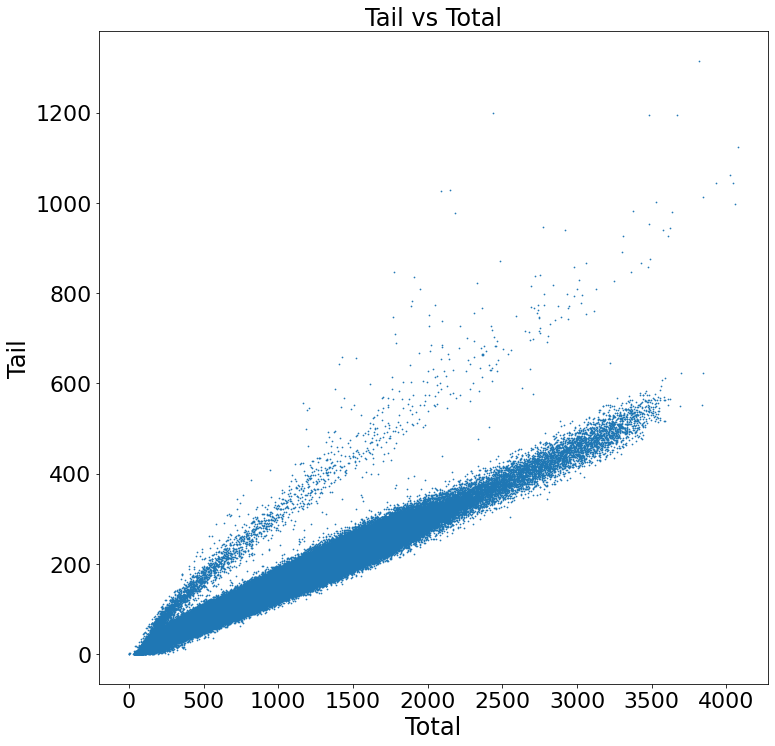

In [11]:
fontsize = 24
label_size = 22

fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    psd_report["ENERGY"], psd_report["ENERGY"] - psd_report["ENERGYSHORT"], s=0.5
)

# ax.set_ylim(0,1000)
ax.set_ylabel("Tail", fontsize=fontsize)
ax.set_xlabel("Total", fontsize=fontsize)
ax.set_title("Tail vs Total", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

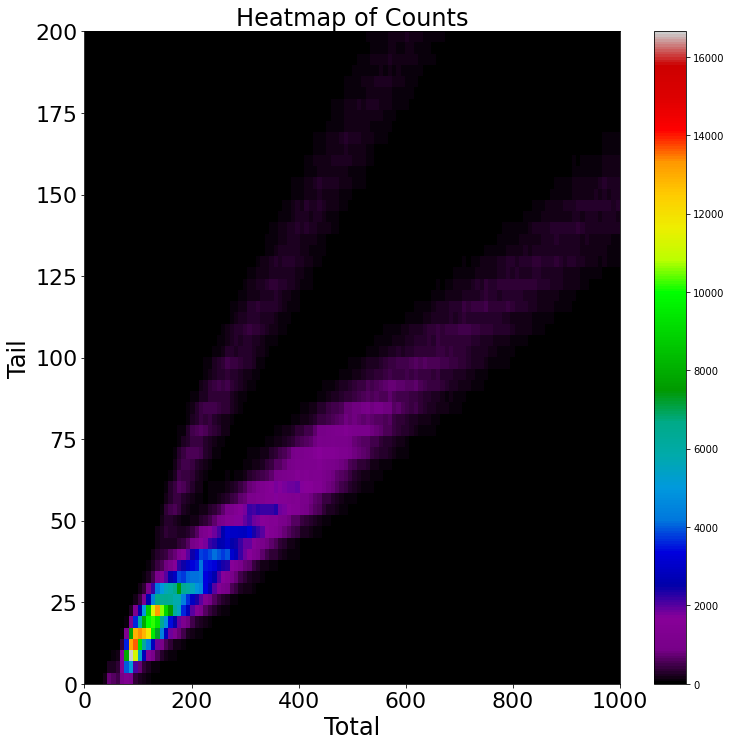

In [5]:
resolution = 500

x_tt, y_tt = psd_report["ENERGY"], psd_report["ENERGY"] - psd_report["ENERGYSHORT"]
Z_tt, xe_tt, ye_tt = np.histogram2d(x_tt, y_tt, resolution)

# generating psd/energy 2D histogram
fig, ax = plt.subplots(figsize=(12,12))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe_tt, ye_tt, Z_tt.T, cmap=cmap)

fontsize = 24
ax.set_xlim(0,1e3)
ax.set_ylim(0,200)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("Tail", fontsize=fontsize)
ax.set_xlabel("Total", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

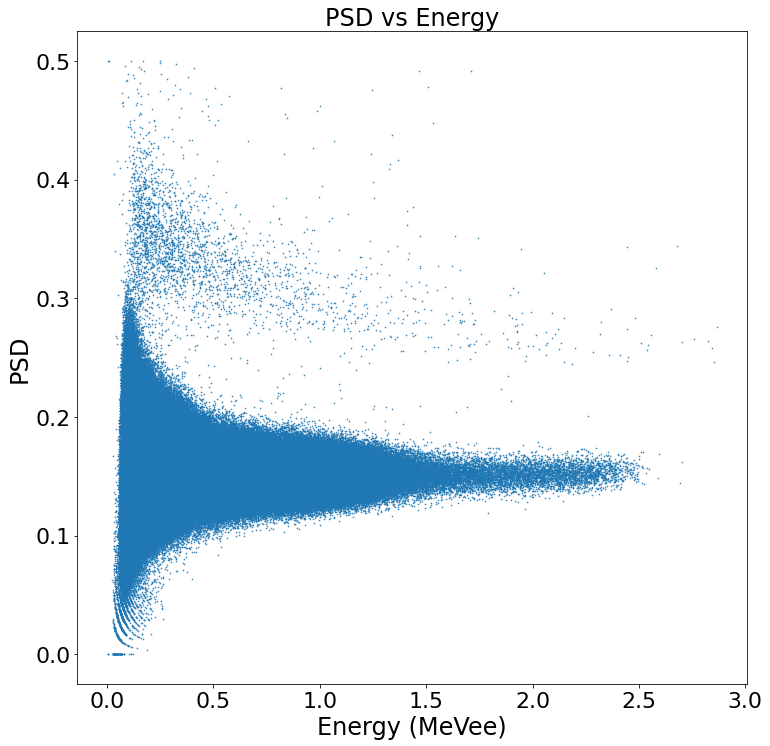

In [12]:
fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    psd_report["CALIB_ENERGY"], psd_report["tail / total"], s=0.5, alpha=0.8
)

ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.set_title("PSD vs Energy", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

## Heatmap & Histograms

In [13]:
resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

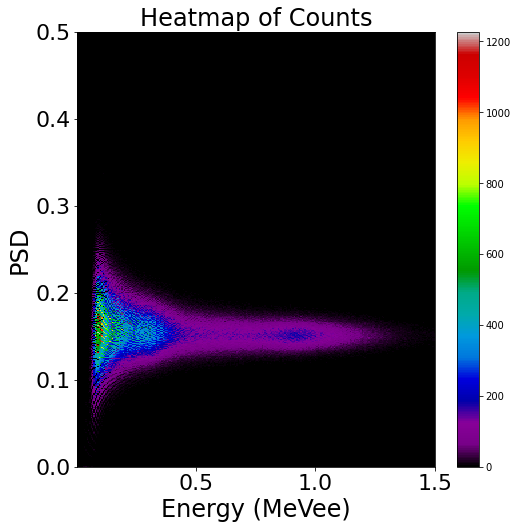

In [14]:
# generating psd/energy 2D histogram
fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

fontsize = 24
ax.set_xlim(xe[0],1.5)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

In [15]:
# slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

Text(0.5, 0, 'Counts')

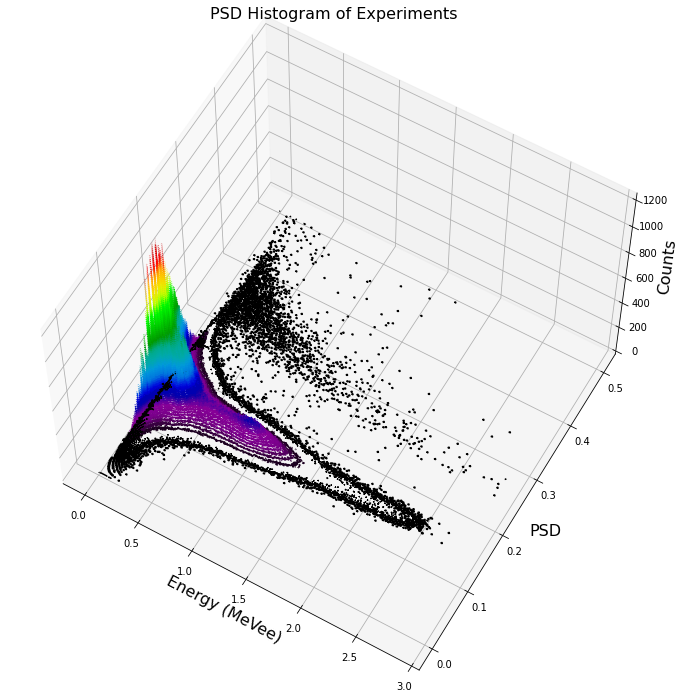

In [16]:
# histogram contour plot (vaporwave island)
contour_res = 120
angle_elev = 60
angle_rot = -60

fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])

ax.view_init(angle_elev, angle_rot)
ax.contour3D(x, y, (Z.T), contour_res, cmap=cmap)
# ax.contour([0.35, 0.35], [0, 0], [100, 100])
ax.set_title("PSD Histogram of Experiments", fontsize=16)
ax.set_ylabel("PSD", fontsize=16)
ax.set_xlabel("Energy (MeVee)", fontsize=16)
ax.set_zlabel("Counts", fontsize=16)
# ax.vlines(0.35, 0, 100)

# FOM Analysis

In [17]:
def split_params(params):
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(bins, histogram_slice, bounds):     
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins, 
    histogram, 
    default_bounds,
    bounds = None, 
    start_idx = 0, 
    end_idx = None,
):
    # end_idx is not inclusive (like end of range())
    
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
#         print(f"default = {default_bounds}\nbounds={bounds}")
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [18]:
psd_bin_lbs = ye[:-1]

# default_bounds = (
#     (0.01, 0.01, 1, 
#      0.25, 0.01, 0),
#     (0.23, 0.1, Z.max(),
#      0.36, 0.036, 1000)
# )


# Default
default_bounds = (
    (0.01, 0.01, 1, 
     0.25, 0.01, 0),
    (0.23, 0.1, Z.max(),
     0.36, 0.05, 1000)
)


# Ranged Example
bounds = [
    ((0,5), default_bounds),
    ((10,12), default_bounds),
    ((5,10), default_bounds)
]

# bounds = None

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.119741,0.01,1.0,0.303854,0.01,5.039462e-05,3.909283
1,1,0.119743,0.01,1.0,0.303854,0.01,5.039465e-05,3.909242
2,2,0.119743,0.01,1.0,0.303854,0.01,5.039465e-05,3.909242
3,3,0.119718,0.01,1.0,0.303854,0.01,5.039466e-05,3.909765
4,4,0.099503,0.01,1.0,0.303854,0.01,4.806007e-11,4.338999


In [26]:
fom_slice = df.query("(0 < fom) & (fom <= 1.5)")
fom_slice

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
5,5,0.010000,0.060612,1.000000,0.360000,0.050000,0.007390,1.343715
6,6,0.114811,0.010000,1.000000,0.300357,0.050000,0.017172,1.313233
7,7,0.040187,0.045059,1.329589,0.250000,0.050000,0.033178,0.937303
10,10,0.119199,0.041493,30.455694,0.359999,0.049883,0.016193,1.119092
11,11,0.129213,0.038715,100.579685,0.250000,0.046166,1.360207,0.604299
12,12,0.138277,0.037640,230.251566,0.250000,0.042391,2.298807,0.592822
13,13,0.145920,0.037831,383.047378,0.250000,0.038724,3.617916,0.577345
14,14,0.150626,0.036853,523.587491,0.250000,0.034174,8.885734,0.594145
15,15,0.154970,0.036229,605.256601,0.250000,0.029217,10.909582,0.616619
16,16,0.156976,0.035801,631.373764,0.250000,0.029851,11.573047,0.601710


In [27]:
# Manually adjust

fom_slice = fom_slice.loc[10,:]

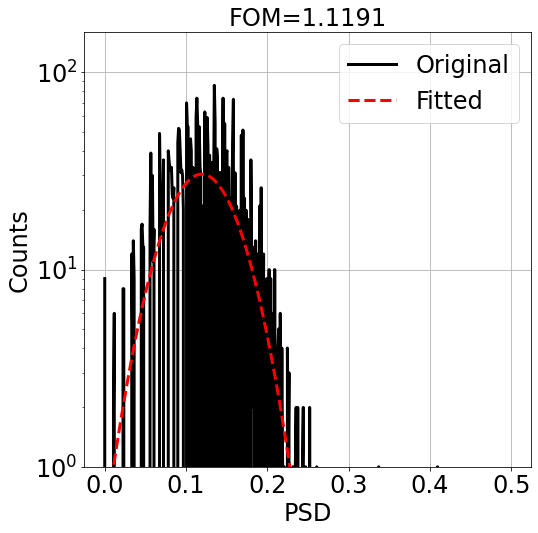

In [31]:
# looking at threshold FOM slice
histogram_slice = Z.T[:,int(fom_slice["i"])]
params = fom_slice[1:-1]
fom = fom_slice["fom"]

fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, histogram_slice, "k", lw=3, label="Original")
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), 'r--', lw=3, label="Fitted")

ax.set_yscale("log")
ax.set_ylim(1)
gamma_params, neutron_params = split_params(params)

ax.set_title(f"FOM={fom:.4f}", fontsize=fontsize)
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize)
ax.grid()

<IPython.core.display.Javascript object>


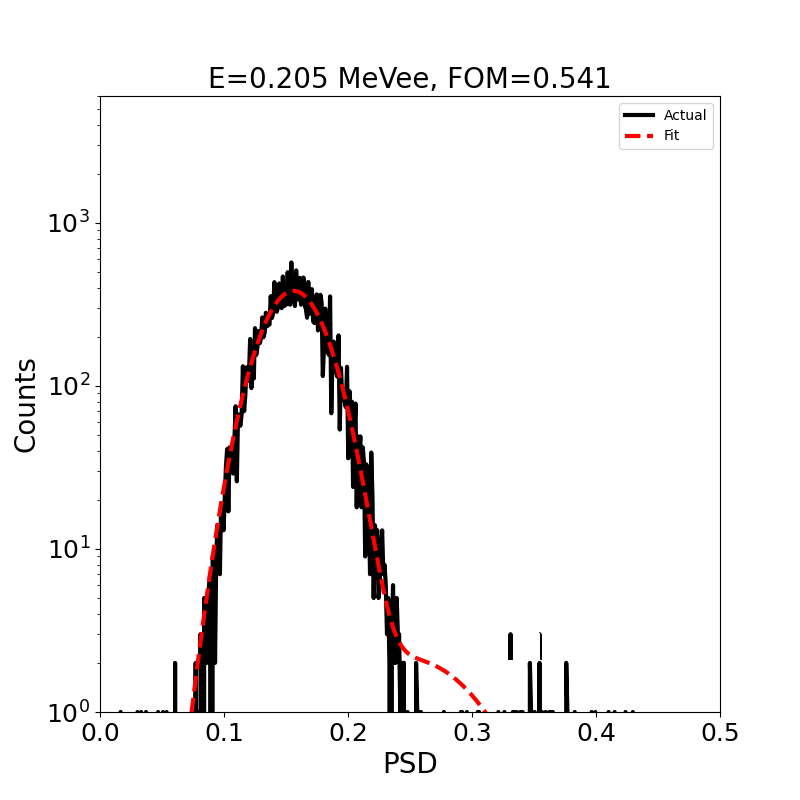

In [32]:
# super-awesome histogram scan animation
%matplotlib notebook
from matplotlib.animation import FuncAnimation

anim_fs = 20
anim_ls = 18

fig = plt.figure(figsize=(8,8))
ax = plt.axes(xlim=(0, 0.5), ylim=(1,6e3), yscale="log")
line1, = ax.plot([], [], 'k', lw=3, label='Actual')
line2, = ax.plot([], [], 'r--', lw=3, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD', fontsize=anim_fs)
    ax.set_ylabel('Counts', fontsize=anim_fs)
    ax.tick_params(axis='both', which='major', labelsize=anim_ls)
    ax.tick_params(axis='both', which='minor', labelsize=anim_ls)
    return line1, line2

def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
    ax.set_title(f"E={xe[i]:.3f} MeVee, FOM={fom:.3f}", fontsize=anim_fs)

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=range(0, 100), interval=30, blit=True)

# anim.save('graph.gif', writer='pillow')

In [33]:
%matplotlib inline

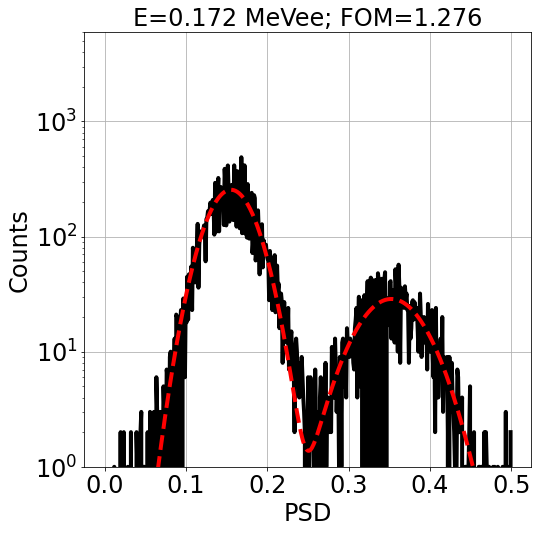

In [27]:
slice_idx = int(fom_slice["i"])

fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, Z.T[:,slice_idx], "k", lw=4)
params = tuple(df.iloc[slice_idx,1:7])
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), "r--", lw=4)
ax.set_ylim(1, 6e3)
ax.grid()
ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.set_title(f"E={xe[slice_idx]:.3f} MeVee; FOM={fom:.3f}", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize)

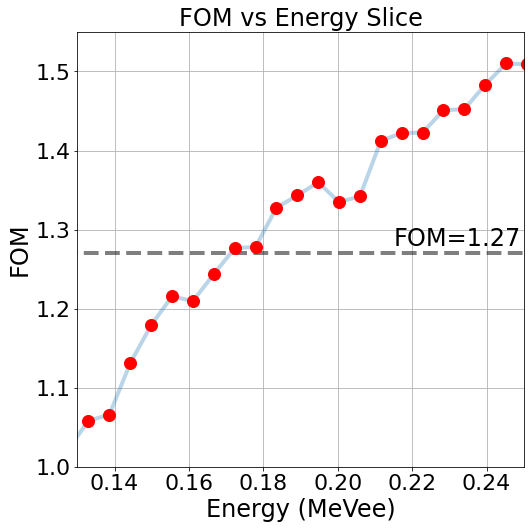

In [28]:
fig, ax = plt.subplots(figsize=(8,8))


ax.hlines(1.27, 0, 1.25, color='k', linestyle='--', alpha=0.5, lw=4)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "-",
    alpha=0.3,
    lw=4
)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "ro",
    markersize=12,
)

ax.text(*(0.215, 1.27 + 0.01), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(1, 1.55)
ax.set_xlim(0.13, 0.25)
ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

# ax.legend(fontsize=fontsize)
ax.grid()
# ax.set_yticks(np.arange(1,2.25,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [35]:
# fom_idx = slice_idx

# fom_fit = interp1d(df["fom"][fom_idx-1:fom_idx+1], xe[fom_idx-1:fom_idx+1], kind="linear")
# L0 = fom_fit(1.27)
L0 = 0.1712
f"FOM ENERGY CUTOFF = {L0:.4f} MeVee"

'FOM ENERGY CUTOFF = 0.1712 MeVee'

# Counting Windows

In [36]:
# window fitting

window_adj_offset = 0

def classify(psd_report, lb_fit_fn, ub_fit_fn, label, le_cutoff=L0):
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons, 
    gammas, 
    lb_fit,
    ub_fit,
    max_energy,
    FOM_cutoff,
    n_neutrons,
    label_a = "Neutrons",
    label_b = "Gammas",
):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_b)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_a)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'k', alpha=0.5)

    ax.set_title(f"N > FOM ={n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0,0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [37]:
all_slice_xs = xe[:end_scan_idx]
sample_frac = 0.1
random_state = 1323

## NASA  


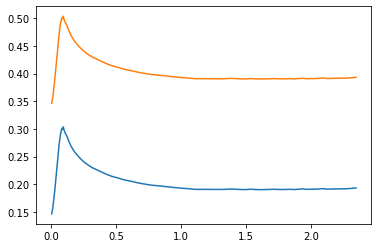

In [38]:
window_offset = 0.2
sigma = 4

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)
neutron_lb_fit = interp1d(all_slice_xs, neutron_lb, fill_value=(neutron_lb[0], neutron_lb[-1]), bounds_error=False)

def neutron_ub_fit(x):
    return neutron_lb_fit(x) + window_offset

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [39]:
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA")

In [40]:
# del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'N > FOM =2508'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

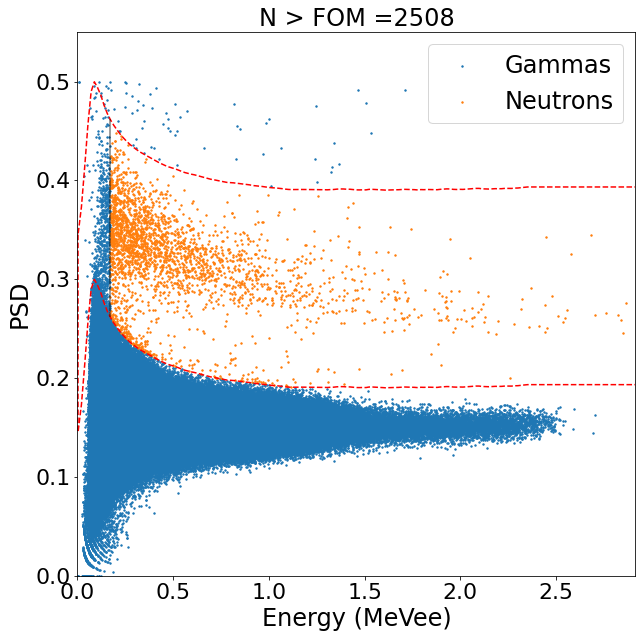

In [41]:
plot_classification(
    psd_report[psd_report["NASA"]], 
    psd_report[~psd_report["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)


# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

## Straight Edge

In [42]:
straight_edge_sigma = 4

slice_start = fom_idx
neutron_straight_lb = df["mu2"][slice_start:] - straight_edge_sigma * df["sigma2"][slice_start:]
neutron_straight_lb_fit = linregress(all_slice_xs[slice_start:], neutron_straight_lb)

NameError: name 'fom_idx' is not defined

In [37]:
f"Lower PSD Cutoff = {neutron_straight_lb_fit.intercept:.4f}"

'Lower PSD Cutoff = 0.2250'

In [38]:
def straight_lb(x):
    return neutron_straight_lb_fit.intercept * np.ones_like(x)

def straight_ub(x):
    return 0.5 * np.ones_like(x)

In [39]:
psd_report = classify(psd_report, straight_lb, straight_ub, "straight")

In [40]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'N > FOM =295133'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

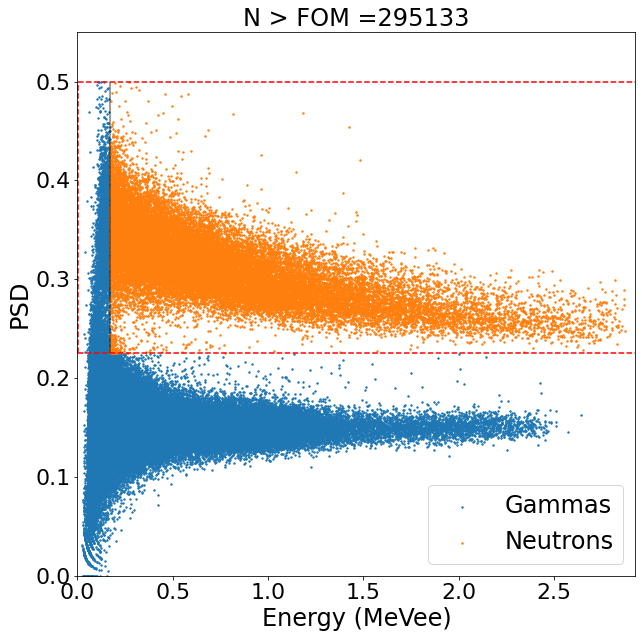

In [41]:
plot_classification(
    graph_sample[graph_sample["straight"]], 
    graph_sample[~graph_sample["straight"]], 
    straight_lb, 
    straight_ub, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["straight"]].shape[0],
)

## Gamma Cover

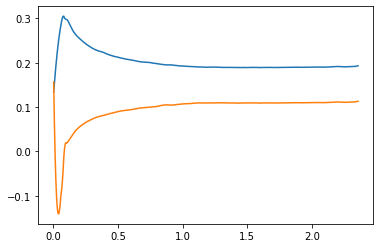

In [42]:
window_offset = 0.2
sigma = 4

gamma_lb = savgol_filter(df["mu1"] - sigma * df["sigma1"], window_length=21, polyorder=3)
gamma_lb_fit = interp1d(all_slice_xs, gamma_lb, fill_value=(gamma_lb[0], gamma_lb[-1]), bounds_error=False)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, gamma_lb_fit(all_slice_xs))

In [43]:
psd_report = classify(psd_report, gamma_lb_fit, neutron_lb_fit, "gamma_cover")

In [44]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'N > FOM =770367'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

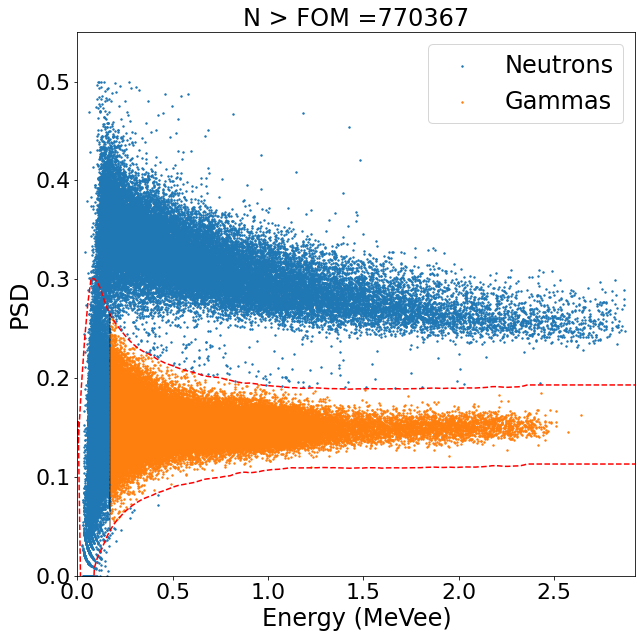

In [45]:
plot_classification(
    graph_sample[graph_sample["gamma_cover"]], 
    graph_sample[~graph_sample["gamma_cover"]], 
    gamma_lb_fit, 
    neutron_lb_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["gamma_cover"]].shape[0],
    "Gammas",
    "Neutrons"
)

## Neutron Cover

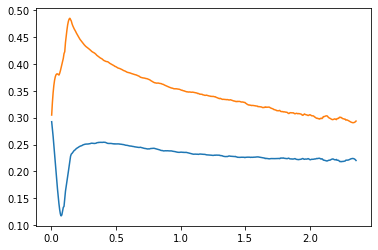

In [49]:
window_offset = 0.2
sigma = 3

nn_lb = savgol_filter(df["mu2"] - sigma * df["sigma2"], window_length=21, polyorder=3)
nn_lb_fit = interp1d(all_slice_xs, nn_lb, fill_value=(nn_lb[0], nn_lb[-1]), bounds_error=False)

nn_ub = savgol_filter(df["mu2"] + sigma * df["sigma2"], window_length=21, polyorder=3)
nn_ub_fit = interp1d(all_slice_xs, nn_ub, fill_value=(nn_ub[0], nn_ub[-1]), bounds_error=False)

plt.plot(all_slice_xs, nn_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, nn_ub_fit(all_slice_xs))

In [50]:
psd_report = classify(psd_report, nn_lb_fit, nn_ub_fit, "neutron_cover")

In [51]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'N > FOM =290745'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

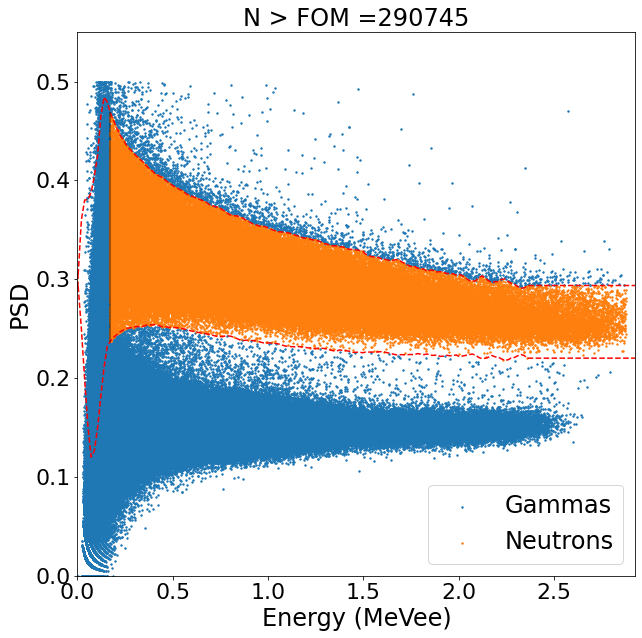

In [52]:
plot_classification(
    psd_report[psd_report["neutron_cover"]], 
    psd_report[~psd_report["neutron_cover"]], 
    nn_lb_fit, 
    nn_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["neutron_cover"]].shape[0],
)

# CPS

In [43]:
def counts_over_time_histogram(df, dwell_time, total_time):
    n_bins = int(total_time / dwell_time)   
    counts, bins = np.histogram(df, n_bins)
    return counts[1:], bins[1:]


def plot_histogram(
    bins, 
    counts,
    labels,
    style = "points"
):
    "Style options: `points`, `stairs`"
    fig, ax = plt.subplots(dpi=120)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o--", label=label)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4)
    
    ax.legend()
    return fig, ax

def omega(a, d):
    return 2*np.pi*(1-(d/np.sqrt(d**2+a**2)))

In [55]:
dwell_time = 1 # s

total_time = psd_report["TIMETAG"].max() * 1e-12 # s
f"Total time = {total_time:.3f}s"

'Total time = 2876.082s'

## NASA Style

In [56]:
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["NASA"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["NASA"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

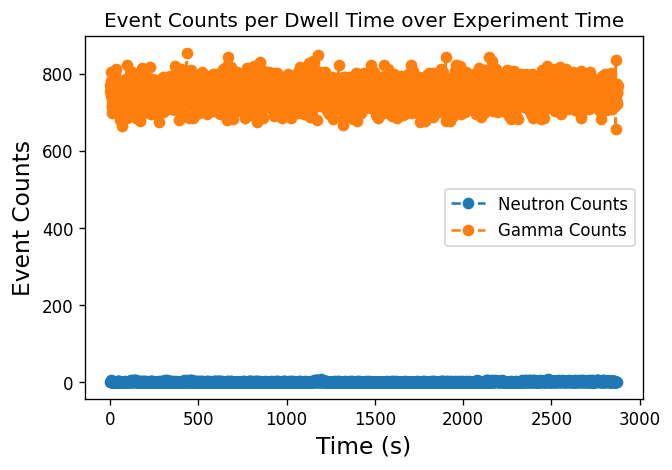

In [57]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [58]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

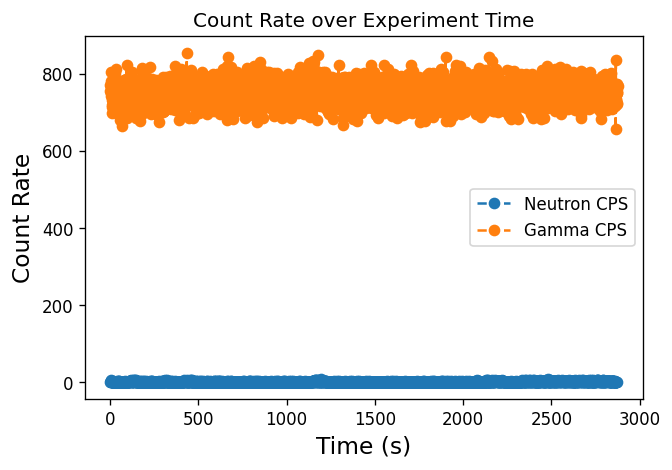

In [59]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [60]:
cps_n_bins = 10

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 19.7000s'

(-1.0, 10.0)

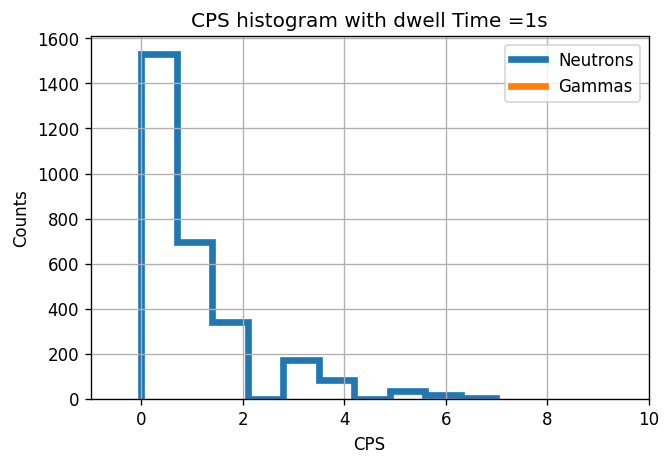

In [61]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")
ax.set_xlim(-1, 10)

## Straight Edge

In [61]:
dwell_time = 1 #s

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["straight"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["straight"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

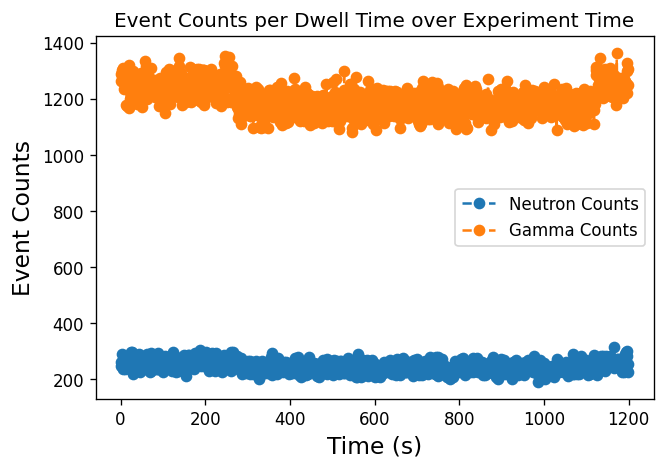

In [62]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [63]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

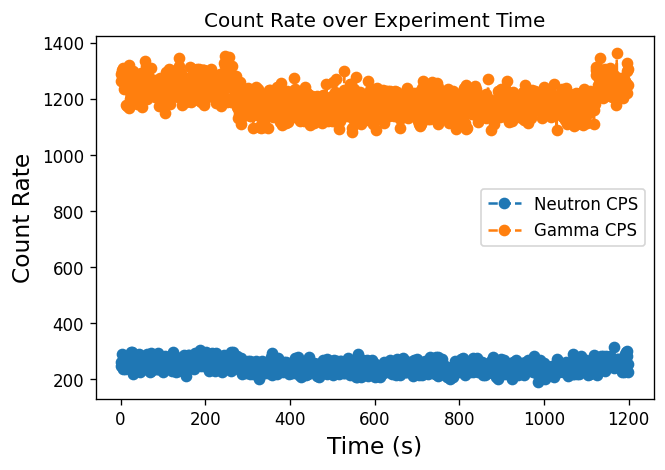

In [64]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [65]:
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 2.2742s'

Text(0.5, 1.0, 'CPS histogram with dwell Time =1s')

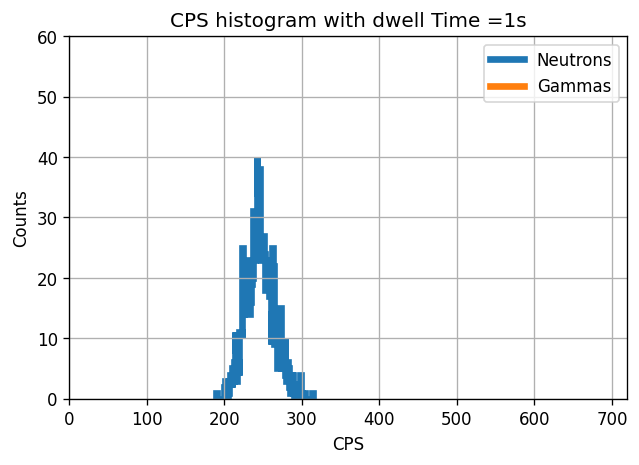

In [66]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
ax.set_ylim(0, 60)
ax.set_xlim(0,720)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")

# Covers

In [71]:
dwell_time = 10 #s

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["neutron_cover"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["gamma_cover"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

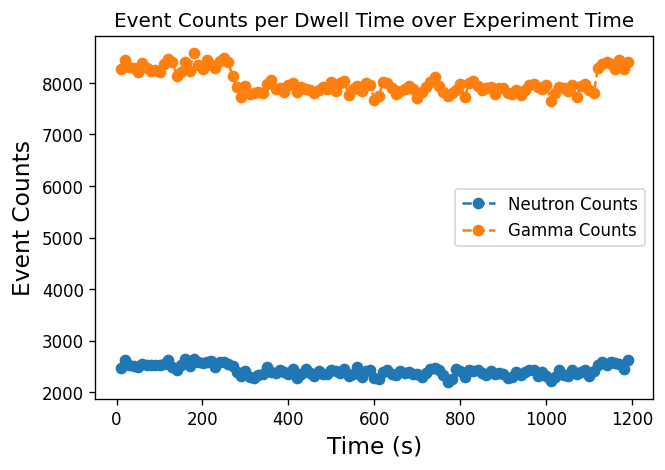

In [72]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [73]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

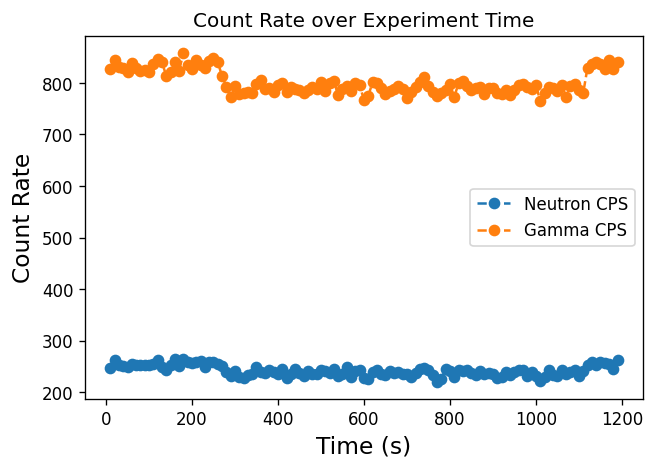

In [74]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [75]:
cps_n_bins = 3

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 31.1667s'

Text(0.5, 1.0, 'CPS histogram with dwell Time =10s')

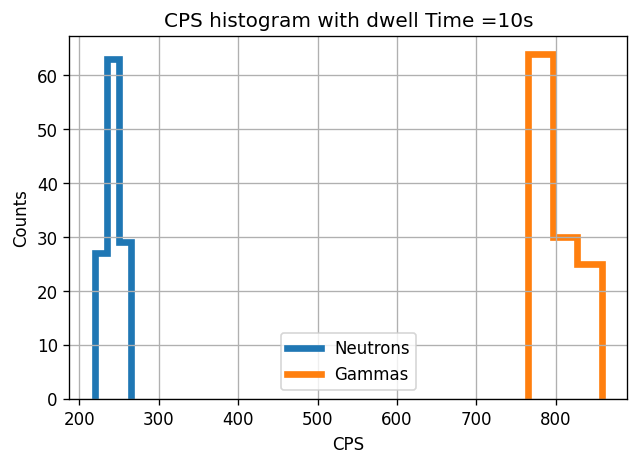

In [76]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")